In [26]:
import pandas as pd
import numpy as np
import seaborn as sns

In [27]:
df = pd.read_csv("clean_shark_df.csv")

In [28]:
df.head(5)

,date,year,type,country,state,location,activity,sex,age,fatal_y/n,time,sex_clean,activity_clean,hour,time_period
0,24th May,2026,Unprovoked,AUSTRALIA,Queensland,Kennedy Shoal,Spearfishing,M,39.0,Y,11:00:00rs,Male,Spearfishing,11.0,Morning
1,17th May,2026,Questionable,UNITED STATES,Maryland,Assateague State Park,Surfing,M,NaN,N,?,Male,Surfing,NaN,NaN
2,16th May,2026,Unprovoked,AUSTRALIA,Western Australia,Horseshoe Reef Rottnest Island,Skindiving,M,38.0,Y,10:00:00rs,Male,Diving,10.0,Morning
3,14th April,2026,Unprovoked,MALDIVES,Gaafu Alif Atoll,Kooddoo,Swimming,M,NaN,N,?,Male,Swimming,NaN,NaN
4,3rd April,2026,Unprovoked,AUSTRALIA,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,M,16.0,N,?,Male,Surfing,NaN,NaN


## Shark attack analysis - Data preparation

In [29]:
# Work on a copy so the original df stays unchanged.
df_analysis = df.copy()

# creating 1:0 values 
df_analysis['case_count'] = 1
df_analysis['is_fatal'] = df_analysis['fatal_y/n'].map({'Y': 1, 'N': 0})

#making sure all nulls appear as Unknown
df_analysis['country_clean'] = df_analysis['country'].fillna('Unknown')
df_analysis['state_clean'] = df_analysis['state'].fillna('Unknown')
df_analysis['location_clean'] = df_analysis['location'].fillna('Unknown')
df_analysis['time_period_clean'] = df_analysis['time_period'].fillna('Unknown')
# bucketing ages
conditions = [
    df_analysis['age'] <= 12,
    df_analysis['age'].between(13, 17),
    df_analysis['age'].between(18, 24),
    df_analysis['age'].between(25, 34),
    df_analysis['age'].between(35, 44),
    df_analysis['age'].between(45, 54),
    df_analysis['age'].between(55, 64),
    df_analysis['age'] >= 65

]

choices = [
    '0-12', '13-17', '18-24', '25-34','35-44', '45-54', '55-64', '65+'
]

df_analysis['age_group'] = np.select(
    conditions,
    choices,
    default='Unknown'
)
#bucketing years into decades
df_analysis['decade'] = (df_analysis['year'] // 10 * 10).astype(str) + 's'
#check new df
df_analysis.head()

,date,year,type,country,state,location,activity,sex,age,fatal_y/n,...,hour,time_period,case_count,is_fatal,country_clean,state_clean,location_clean,time_period_clean,age_group,decade
0,24th May,2026,Unprovoked,AUSTRALIA,Queensland,Kennedy Shoal,Spearfishing,M,39.0,Y,...,11.0,Morning,1,1.0,AUSTRALIA,Queensland,Kennedy Shoal,Morning,35-44,2020s
1,17th May,2026,Questionable,UNITED STATES,Maryland,Assateague State Park,Surfing,M,NaN,N,...,NaN,NaN,1,0.0,UNITED STATES,Maryland,Assateague State Park,Unknown,Unknown,2020s
2,16th May,2026,Unprovoked,AUSTRALIA,Western Australia,Horseshoe Reef Rottnest Island,Skindiving,M,38.0,Y,...,10.0,Morning,1,1.0,AUSTRALIA,Western Australia,Horseshoe Reef Rottnest Island,Morning,35-44,2020s
3,14th April,2026,Unprovoked,MALDIVES,Gaafu Alif Atoll,Kooddoo,Swimming,M,NaN,N,...,NaN,NaN,1,0.0,MALDIVES,Gaafu Alif Atoll,Kooddoo,Unknown,Unknown,2020s
4,3rd April,2026,Unprovoked,AUSTRALIA,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,M,16.0,N,...,NaN,NaN,1,0.0,AUSTRALIA,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Unknown,13-17,2020s


## Overall attack summary

In [30]:
total_attacks = len(df_analysis)
known_outcomes = df_analysis['is_fatal'].notna().sum()
#creating a Series summary 
overall_summary = pd.Series({
    'total_attacks': total_attacks,
    'fatal_attacks': int(df_analysis['is_fatal'].sum()),
    'non_fatal_attacks': int((df_analysis['is_fatal'] == 0).sum()),
    'unknown_outcome_attacks': int(df_analysis['is_fatal'].isna().sum()),
    'fatality_rate_known_outcomes_pct': round(df_analysis['is_fatal'].mean() * 100, 1),
    'average_age': round(df_analysis['age'].mean(), 1),
    'most_common_country': df_analysis['country_clean'].mode().iat[0],
    'most_common_activity': df_analysis['activity_clean'].mode().iat[0],
    'most_common_time_period': df_analysis.loc[df_analysis['time_period'].notna(), 'time_period'].mode().iat[0],
    'peak_year': int(df_analysis['year'].value_counts().idxmax())
}).to_frame('value')

overall_summary

,value
total_attacks,3964
fatal_attacks,436
non_fatal_attacks,3225
unknown_outcome_attacks,303
fatality_rate_known_outcomes_pct,11.9
average_age,29.9
most_common_country,UNITED STATES
most_common_activity,Surfing
most_common_time_period,Afternoon
peak_year,2015


## Reusable aggregation helper

In [31]:
# creating a function to use to prepare a summary by choosing any value to aggregate the data by 
def summarize_by(column, top_n=20, min_known_outcomes=0):
    summary = (
        df_analysis
        .groupby(column, dropna=False)
        .agg(
            attacks=('case_count', 'sum'),
            fatal_attacks=('is_fatal', 'sum'),
            known_outcomes=('is_fatal', 'count'),
            avg_age=('age', 'mean'),
            median_age=('age', 'median'),
            countries=('country_clean', 'nunique')
        )
        .assign(
            attack_share_pct=lambda x: (x['attacks'] / len(df_analysis) * 100).round(1),
            fatality_rate_pct=lambda x: (x['fatal_attacks'] / x['known_outcomes'] * 100).round(1),
            avg_age=lambda x: x['avg_age'].round(1),
            median_age=lambda x: x['median_age'].round(1)
        )
        .sort_values(['attacks', 'fatal_attacks'], ascending=False)
    )

    summary = summary[summary['known_outcomes'] >= min_known_outcomes]

    return summary.head(top_n)


## Aggregations by country, state, activity, sex, age, and time

In [32]:
country_summary = summarize_by('country_clean', top_n=10)
country_summary

,attacks,fatal_attacks,known_outcomes,avg_age,median_age,countries,attack_share_pct,fatality_rate_pct
country_clean,,,,,,,,
UNITED STATES,1882,62.0,1767,28.1,24.0,1,47.5,3.5
AUSTRALIA,719,86.0,658,32.1,30.0,1,18.1,13.1
SOUTH AFRICA,349,42.0,310,28.2,25.0,1,8.8,13.5
BRAZIL,113,32.0,103,24.3,21.0,1,2.9,31.1
BAHAMAS,113,7.0,106,37.2,35.0,1,2.9,6.6
NEW ZEALAND,72,7.0,67,27.1,24.0,1,1.8,10.4
NEW CALEDONIA,59,21.0,57,35.4,36.0,1,1.5,36.8
REUNION,58,27.0,57,30.9,28.0,1,1.5,47.4
MEXICO,50,15.0,45,33.8,32.5,1,1.3,33.3


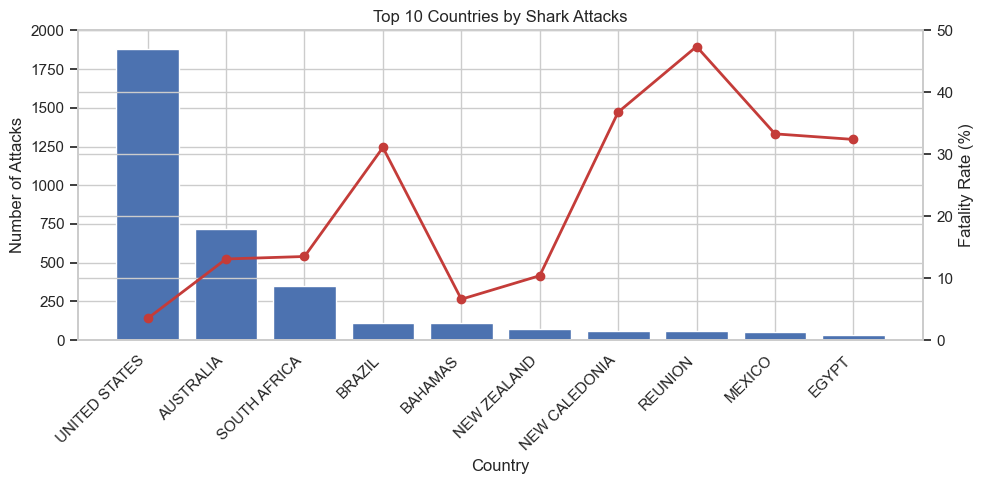

In [33]:
import matplotlib.pyplot as plt

country_plot = country_summary.reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart for attacks
ax1.bar(
    country_plot['country_clean'],
    country_plot['attacks']
)

ax1.set_xlabel('Country')
ax1.set_ylabel('Number of Attacks')
ax1.set_ylim(0, 2000)

# Rotate country names
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

# Line chart for fatality rate
ax2 = ax1.twinx()

ax2.plot(
    country_plot['country_clean'],
    country_plot['fatality_rate_pct'],
    marker='o',
    color='#c43c39',
    linewidth=2
)

ax2.set_ylabel('Fatality Rate (%)')
ax2.set_ylim(0, 50)

plt.title('Top 10 Countries by Shark Attacks')
plt.tight_layout()
plt.show()

In [34]:
state_summary = summarize_by('state_clean', top_n=20)
state_summary

,attacks,fatal_attacks,known_outcomes,avg_age,median_age,countries,attack_share_pct,fatality_rate_pct
state_clean,,,,,,,,
Florida,975,16.0,930,25.8,21.0,1,24.6,1.7
Hawaii,250,23.0,229,39.4,39.5,1,6.3,10.0
New South Wales,238,17.0,221,32.2,30.0,1,6.0,7.7
California,224,13.0,208,34.6,32.0,1,5.7,6.2
Western Australia,170,26.0,158,34.7,32.0,1,4.3,16.5
Unknown,166,39.0,147,35.0,33.0,65,4.2,26.5
Queensland,162,22.0,145,31.3,29.0,1,4.1,15.2
Western Cape Province,126,18.0,118,29.7,27.0,1,3.2,15.3
Eastern Cape Province,122,15.0,117,26.6,23.5,1,3.1,12.8


In [35]:
activity_summary = summarize_by('activity_clean', top_n=10)
activity_summary

,attacks,fatal_attacks,known_outcomes,avg_age,median_age,countries,attack_share_pct,fatality_rate_pct
activity_clean,,,,,,,,
Surfing,1486,103.0,1432,27.5,24.0,37,37.5,7.2
Swimming,814,124.0,747,29.8,24.0,58,20.5,16.6
Other,387,43.0,358,28.0,23.0,54,9.8,12.0
Fishing,346,24.0,327,37.0,36.0,50,8.7,7.3
Diving,311,67.0,272,37.0,34.0,50,7.8,24.6
Spearfishing,267,33.0,247,32.4,31.0,34,6.7,13.4
Unknown,217,22.0,147,23.5,20.0,33,5.5,15.0
Snorkeling,136,20.0,131,37.0,35.0,24,3.4,15.3


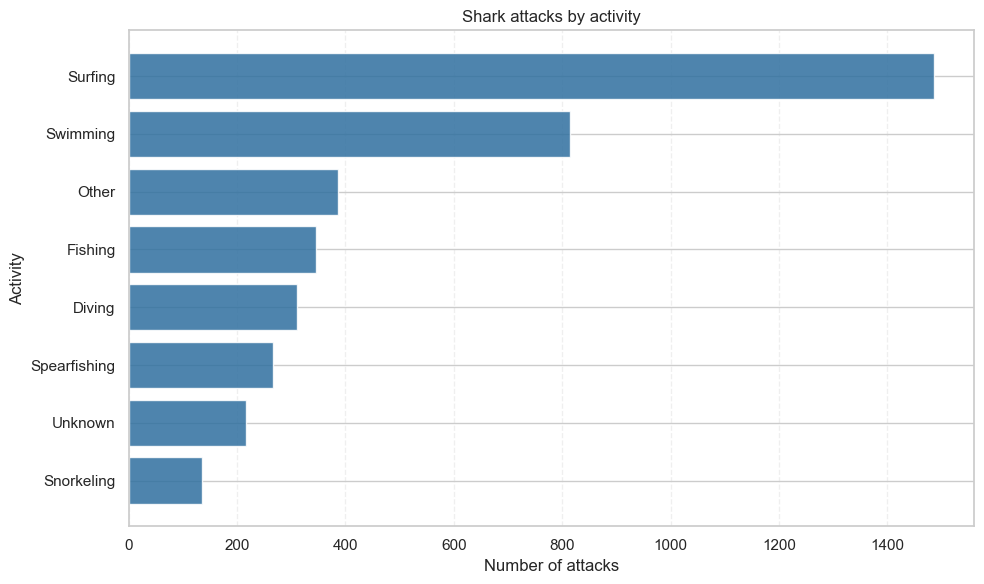

In [36]:
activity_plot = activity_summary.sort_values('attacks', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    activity_plot.index,
    activity_plot['attacks'],
    color='#2f6f9f',
    alpha=0.85
)

ax.set_title('Shark attacks by activity')
ax.set_xlabel('Number of attacks')
ax.set_ylabel('Activity')
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
sex_summary = summarize_by('sex_clean')
sex_summary

,attacks,fatal_attacks,known_outcomes,avg_age,median_age,countries,attack_share_pct,fatality_rate_pct
sex_clean,,,,,,,,
Male,3096,344.0,2875,30.2,27.0,106,78.1,12.0
Female,639,61.0,593,28.8,23.0,52,16.1,10.3
Unknown,229,31.0,193,23.7,17.0,41,5.8,16.1


In [38]:
age_group_summary = summarize_by('age_group')
age_group_summary_sorted = age_group_summary.sort_values('age_group', ascending=True)

age_group_summary_sorted

,attacks,fatal_attacks,known_outcomes,avg_age,median_age,countries,attack_share_pct,fatality_rate_pct
age_group,,,,,,,,
0-12,260,5.0,238,9.6,10.0,19,6.6,2.1
13-17,440,36.0,422,15.2,15.0,28,11.1,8.5
18-24,579,74.0,551,20.8,21.0,40,14.6,13.4
25-34,595,68.0,563,29.1,29.0,49,15.0,12.1
35-44,414,57.0,387,39.1,39.0,47,10.4,14.7
45-54,294,39.0,271,49.1,49.0,36,7.4,14.4
55-64,172,29.0,164,58.7,58.0,29,4.3,17.7
65+,75,18.0,68,70.6,69.0,17,1.9,26.5
Unknown,1135,110.0,997,NaN,NaN,85,28.6,11.0


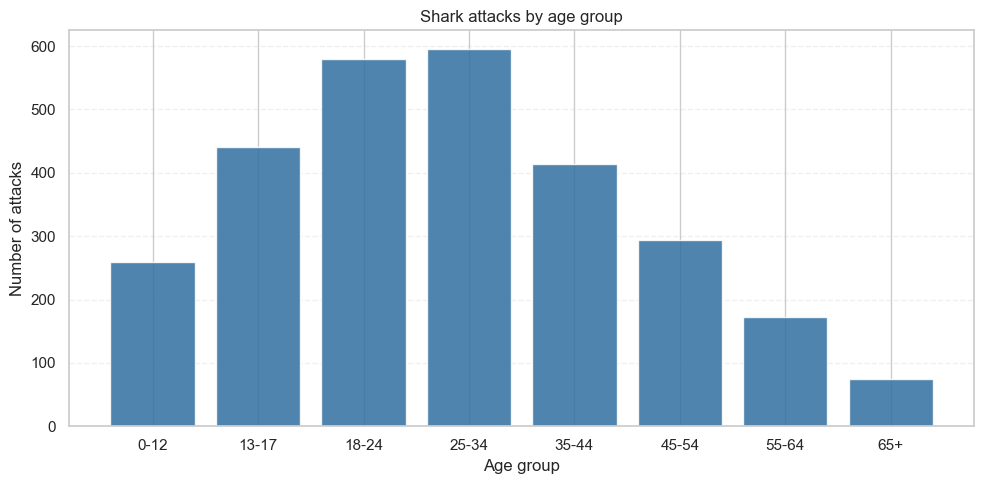

In [39]:
age_group_plot = age_group_summary_sorted.drop(index='Unknown', errors='ignore').reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(age_group_plot['age_group'], age_group_plot['attacks'], color='#2f6f9f', alpha=0.85)
ax.set_title('Shark attacks by age group')
ax.set_xlabel('Age group')
ax.set_ylabel('Number of attacks')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
time_period_summary = summarize_by('time_period_clean')
time_period_summary

,attacks,fatal_attacks,known_outcomes,avg_age,median_age,countries,attack_share_pct,fatality_rate_pct
time_period_clean,,,,,,,,
Unknown,1735,204.0,1514,29.0,26.0,107,43.8,13.5
Afternoon,1014,111.0,988,28.6,24.0,40,25.6,11.2
Morning,805,89.0,774,34.6,33.0,41,20.3,11.5
Evening,376,25.0,353,26.0,22.0,27,9.5,7.1
Night,34,7.0,32,31.0,24.0,12,0.9,21.9


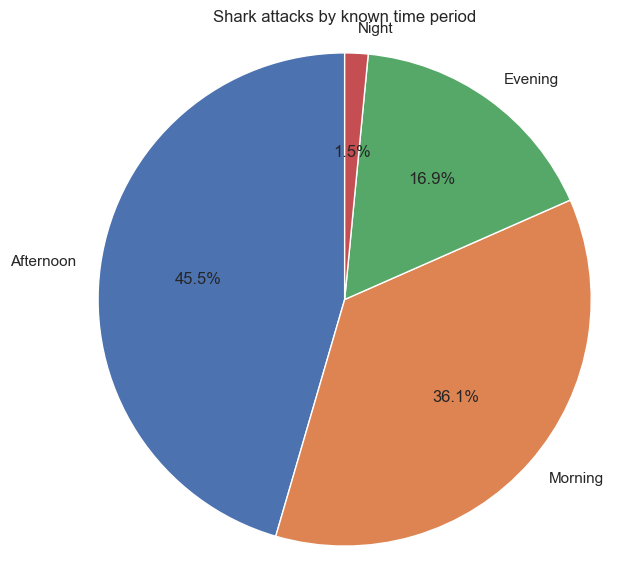

In [41]:
time_period_plot = time_period_summary.drop(index='Unknown', errors='ignore')

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    time_period_plot['attacks'],
    labels=time_period_plot.index,
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title('Shark attacks by known time period')
ax.axis('equal')

plt.show()

In [42]:
type_summary = summarize_by('type')
type_summary

,attacks,fatal_attacks,known_outcomes,avg_age,median_age,countries,attack_share_pct,fatality_rate_pct
type,,,,,,,,
Unprovoked,3132,388.0,3093,29.2,25.0,92,79.0,12.5
Provoked,299,6.0,293,33.8,32.0,44,7.5,2.0
Invalid,267,6.0,22,31.3,28.0,44,6.7,27.3
Watercraft,176,2.0,174,38.3,36.5,17,4.4,1.1
Sea Disaster,45,26.0,44,39.2,39.5,18,1.1,59.1
Questionable,30,8.0,25,41.2,39.5,10,0.8,32.0
Unknown,15,0.0,10,39.3,44.0,7,0.4,0.0


## Yearly and decade-level trends

In [43]:
yearly_summary = (
    df_analysis
    .groupby('year')
    .agg(
        attacks=('case_count', 'sum'),
        fatal_attacks=('is_fatal', 'sum'),
        known_outcomes=('is_fatal', 'count'),
        avg_age=('age', 'mean')
    )
    .assign(
        fatality_rate_pct=lambda x: (x['fatal_attacks'] / x['known_outcomes'] * 100).round(1),
        avg_age=lambda x: x['avg_age'].round(1)
    )
)

yearly_summary.tail(27)

,attacks,fatal_attacks,known_outcomes,avg_age,fatality_rate_pct
year,,,,,
2000,97,18.0,91,31.4,19.8
2001,92,6.0,87,27.6,6.9
2002,88,10.0,84,28.5,11.9
2003,92,8.0,86,27.7,9.3
2004,92,14.0,83,29.3,16.9
2005,103,7.0,91,28.9,7.7
2006,103,10.0,93,27.2,10.8
2007,113,5.0,101,29.9,5.0
2008,122,10.0,110,28.6,9.1


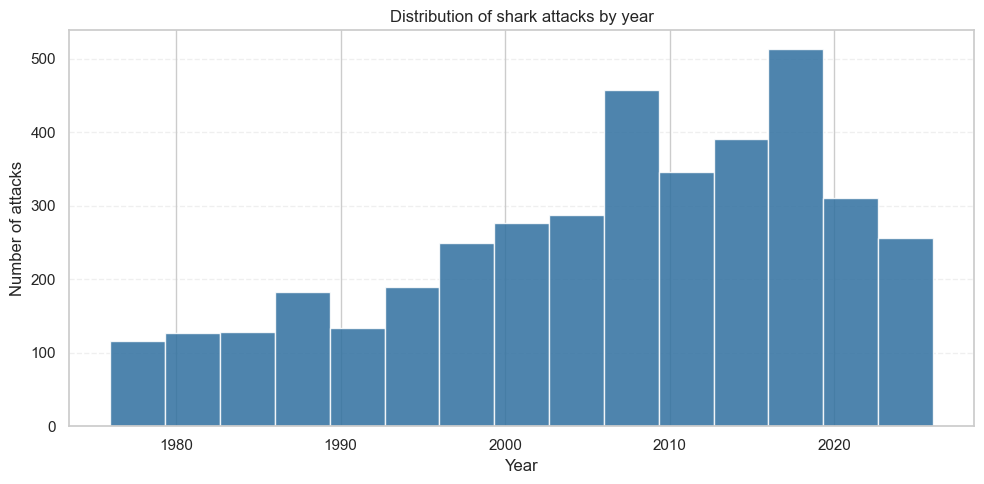

In [44]:
yearly_plot = yearly_summary.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    yearly_plot['year'],
    bins=15,
    weights=yearly_plot['attacks'],
    color='#2f6f9f',
    edgecolor='white',
    alpha=0.85
)

ax.set_title('Distribution of shark attacks by year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of attacks')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
decade_summary = (
    df_analysis
    .groupby('decade')
    .agg(
        attacks=('case_count', 'sum'),
        fatal_attacks=('is_fatal', 'sum'),
        known_outcomes=('is_fatal', 'count'),
        countries=('country_clean', 'nunique'),
        avg_age=('age', 'mean')
    )
    .assign(
        fatality_rate_pct=lambda x: (x['fatal_attacks'] / x['known_outcomes'] * 100).round(1),
        avg_age=lambda x: x['avg_age'].round(1)
    )
)

decade_summary

,attacks,fatal_attacks,known_outcomes,countries,avg_age,fatality_rate_pct
decade,,,,,,
1970s,116,20.0,106,13,25.5,18.9
1980s,438,52.0,379,35,25.4,13.7
1990s,572,90.0,532,33,27.0,16.9
2000s,1022,101.0,936,64,28.9,10.8
2010s,1250,88.0,1159,71,31.8,7.6
2020s,566,85.0,549,48,33.6,15.5


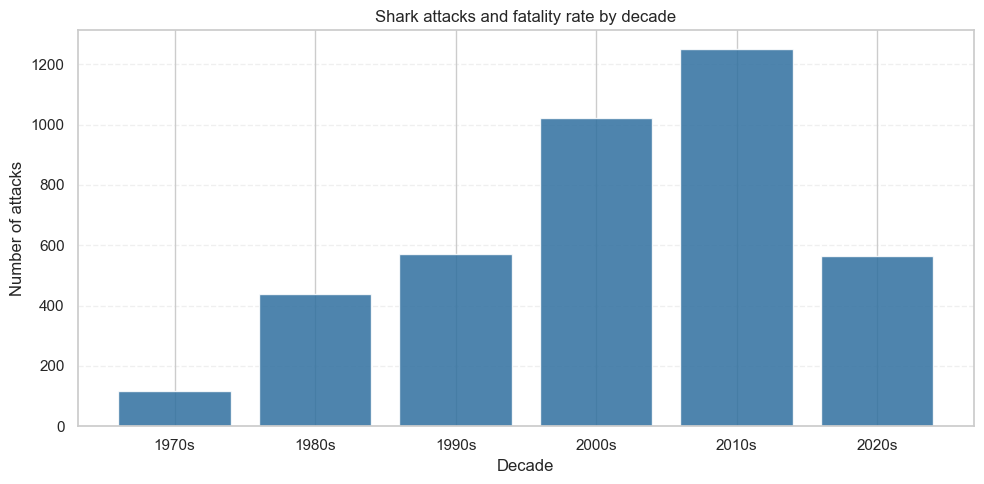

In [46]:
decade_plot = decade_summary.reset_index().copy()
decade_plot['decade_start'] = decade_plot['decade'].str[:4].astype(int)
decade_plot = decade_plot.sort_values('decade_start')

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    decade_plot['decade'],
    decade_plot['attacks'],
    color='#2f6f9f',
    alpha=0.85
)
ax1.set_title('Shark attacks and fatality rate by decade')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Number of attacks')
ax1.grid(axis='y', linestyle='--', alpha=0.3)



plt.tight_layout()
plt.show()

/var/folders/6h/fxdk7zss6pbb3fd61nq6q__c0000gq/T/ipykernel_73933/2715076349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


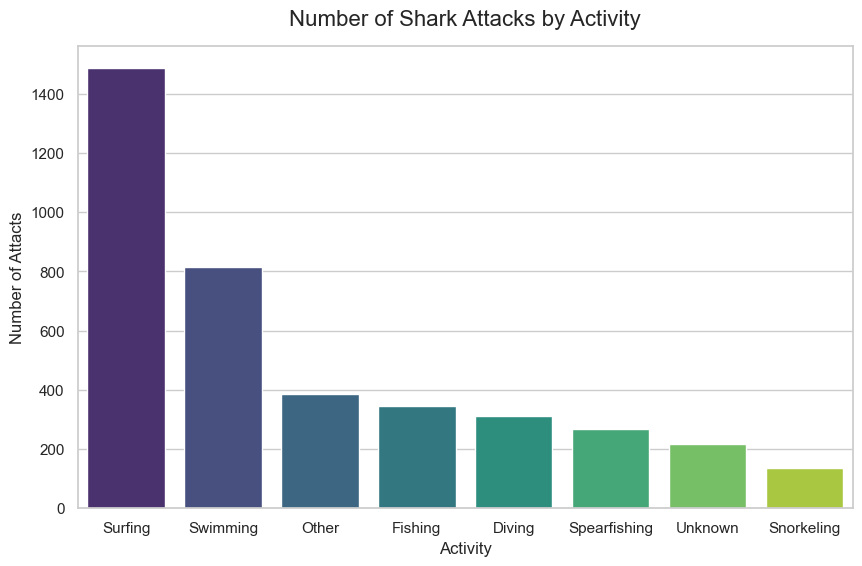

In [47]:
# set the style and figure size (plotting area)
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

# Create a bar plot of the asctivity counts
sns.countplot(
    data=df_analysis,
    x="activity_clean",
    order=df_analysis["activity_clean"].value_counts().index,
    palette="viridis"
)
# Add titles and labels
plt.title("Number of Shark Attacks by Activity", fontsize=16, pad=15)
plt.xlabel("Activity", fontsize=12)
plt.ylabel("Number of Attacts", fontsize=12)
# Display the plot
plt.show()

In [49]:
# laying the groundwork to analyze the breakdown of shark incident by sex using pie chart
plt.figure(figsize=(6, 6))
# get the data counts
sex_counts = df_analysis["sex_clean"].value_counts()

<Figure size 600x600 with 0 Axes>

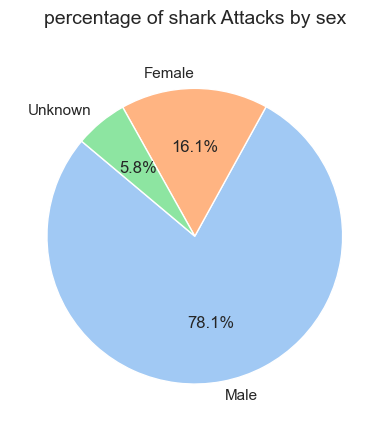

In [50]:
# create a pie chart
plt.pie(
    sex_counts,
    labels=sex_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel")
)
# Add a title
plt.title("percentage of shark Attacks by sex", fontsize=14, pad=20)
plt.show()

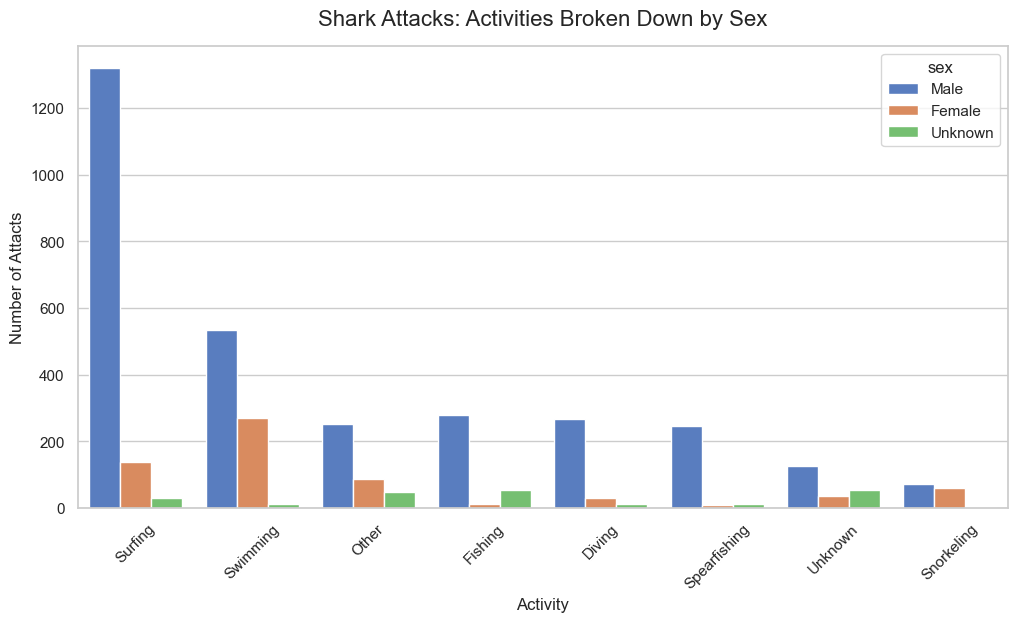

In [52]:
# activity breakdown by sex
plt.figure(figsize=(12, 6))
# Create a bar chart that breaks down activities by sex
sns.countplot(
    data=df_analysis,
    x="activity_clean",
    hue="sex_clean",
    order=df_analysis["activity_clean"].value_counts().index,
    palette="muted"
)
# Addtitles and labels
plt.title("Shark Attacks: Activities Broken Down by Sex", fontsize=16, pad=15)
plt.xlabel("Activity", fontsize=12)
plt.ylabel("Number of Attacts", fontsize=12)
plt.xticks(rotation=45) # Tilts text so it doesn't overlap
plt.legend(title="sex")
# Display the plot
plt.show()

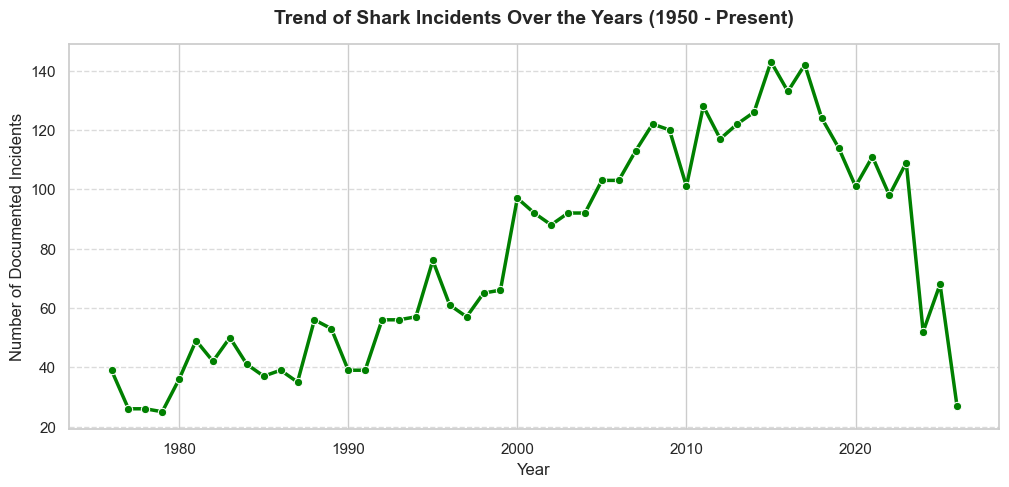

In [53]:
# Filter out placeholder years (loke 0 or NaN) and look at modern data
modern_df = df_analysis[df_analysis["year"] >= 1950]
# Group by year and count the total incidents
yearly_counts = modern_df["year"].value_counts().sort_index()
# create a line plot
plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker="o", color="green", linewidth=2.5)
# Add titles and lables
plt.title("Trend of Shark Incidents Over the Years (1950 - Present)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Documented Incidents", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display the plot
plt.show()

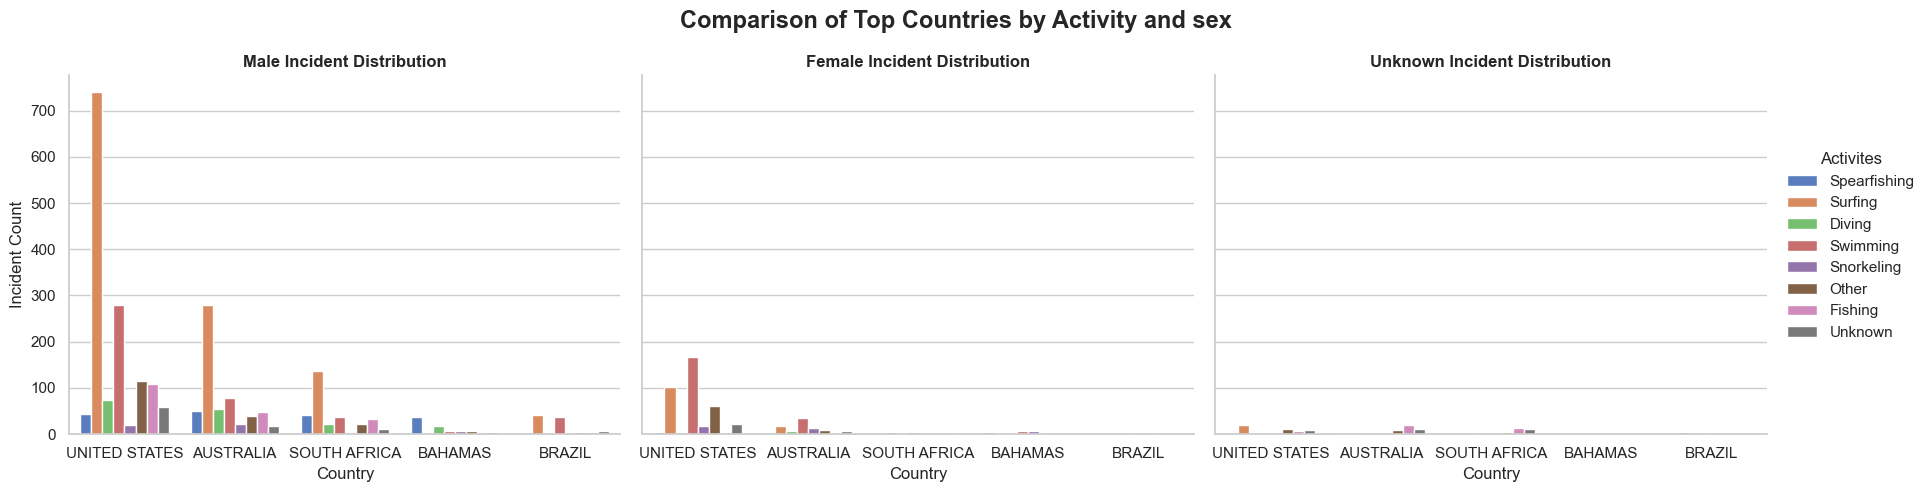

In [55]:
# Identify the top 5 countries with the most incidents
top_countries = df_analysis["country"].value_counts().head(5).index
# Create a smaller temporary dataframe with just those top countries
df_top_locations = df_analysis[df_analysis["country"].isin(top_countries)]
# Create a multi-plot layout(one chart  Males, one for Females)
g = sns.catplot(
    data=df_top_locations,
    x="country",
    hue="activity_clean",
    col="sex_clean",
    kind="count",
    palette="muted",
    height=5,
    aspect=1.2,
    order=top_countries
)
# perfect the stylying and labels
g.set_axis_labels("Country", "Incident Count", fontsize=12)
g.set_titles("{col_name} Incident Distribution", fontweight="bold")
g._legend.set_title("Activites")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Comparison of Top Countries by Activity and sex", fontsize=17, fontweight="bold")
# Display the plot
plt.show()

In [48]:
# Final conclusion using the analysis results above
first_year = int(df_analysis['year'].min())
last_year = int(df_analysis['year'].max())
total_attacks = len(df_analysis)

fatal_attacks = int(df_analysis['is_fatal'].sum())
known_outcomes = int(df_analysis['is_fatal'].notna().sum())
fatality_rate = round(df_analysis['is_fatal'].mean() * 100, 1)

first_country = country_summary.index[0]
second_country = country_summary.index[1]
third_country = country_summary.index[2]

first_activity = activity_summary.index[0]
first_activity_attacks = int(activity_summary.loc[first_activity, 'attacks'])

first_sex = sex_summary.index[0]
average_age = round(df_analysis['age'].mean(), 1)

known_time_periods = time_period_summary.drop(index='Unknown', errors='ignore')
most_common_time_period = known_time_periods.index[0]

peak_year = int(yearly_summary['attacks'].idxmax())
peak_year_attacks = int(yearly_summary.loc[peak_year, 'attacks'])

takeaways = [
    f"The dataset contains {total_attacks:,} shark attacks from {first_year} to {last_year}.",
    f"Most attacks happened in {first_country}, followed by {second_country} and {third_country}.",
    f"The most common activity was {first_activity}, with {first_activity_attacks:,} recorded attacks.",
    f"There were {fatal_attacks:,} fatal attacks among {known_outcomes:,} cases with a known outcome, giving a fatality rate of {fatality_rate}%.",
    f"The most common sex category was {first_sex}, and the average recorded age was {average_age} years old.",
    f"For attacks with a known time period, the most common time period was {most_common_time_period}.",
    f"The year with the most recorded attacks was {peak_year}, with {peak_year_attacks} attacks.",
    f"Overall, shark attacks in this dataset are concentrated by country and activity, especially where water-sport exposure is high."
]

print('Final conclusion')
for takeaway in takeaways:
    print('-', takeaway)

Final conclusion
- The dataset contains 3,964 shark attacks from 1976 to 2026.
- Most attacks happened in UNITED STATES, followed by AUSTRALIA and SOUTH AFRICA.
- The most common activity was Surfing, with 1,486 recorded attacks.
- There were 436 fatal attacks among 3,661 cases with a known outcome, giving a fatality rate of 11.9%.
- The most common sex category was Male, and the average recorded age was 29.9 years old.
- For attacks with a known time period, the most common time period was Afternoon.
- The year with the most recorded attacks was 2015, with 143 attacks.
- Overall, shark attacks in this dataset are concentrated by country and activity, especially where water-sport exposure is high.
